In [2]:
pip install pysid

Note: you may need to restart the kernel to use updated packages.


In [ ]:

# IDENTIFICACIÓN DE SISTEMAS PARAMÉTRICOS

# OBJETIVO:
# Implementar técnicas de identificación paramétrica
# evaluando diferentes estructuras y órdenes de modelos
# para representar un sistema dinámico a partir de datos
# experimentales de entrada y salida.

# ESTRUCTURAS A EVALUAR:
# 1. ARMAX
# 2. OE

# ============================================================
# LIBRERÍAS NECESARIAS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import dlti, dlsim
from pysid import arx, armax, bj, oe
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)



In [10]:
def calcular_metricas(y_real, y_pred):

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))

    mae = mean_absolute_error(y_real, y_pred)

    r2 = r2_score(y_real, y_pred)

    return rmse, mae, r2


In [2]:
# ============================================================
# CARGA DE DATOS

# Se leen los datos experimentales almacenados en un CSV
data = pd.read_csv("D5.csv")
data.head() # Muestra las primeras filas del DataFrame para verificar la carga de datos


,t,u,y,uv,yv
0,0.00,1,0.000000,2.5,0.000000
1,0.01,1,0.214428,2.5,0.243912
2,0.02,1,0.885232,2.5,0.943198
3,0.03,1,0.072755,2.5,0.158252
4,0.04,1,0.672054,2.5,0.784173


In [3]:
# Vectores
t = np.array(data.t) # Tiempo
u = np.array(data.u) # Entrada
y = np.array(data.y) # Salida
uv = np.array(data.uv) # Entrada de validación
yv = np.array(data.yv) # Salida de validación


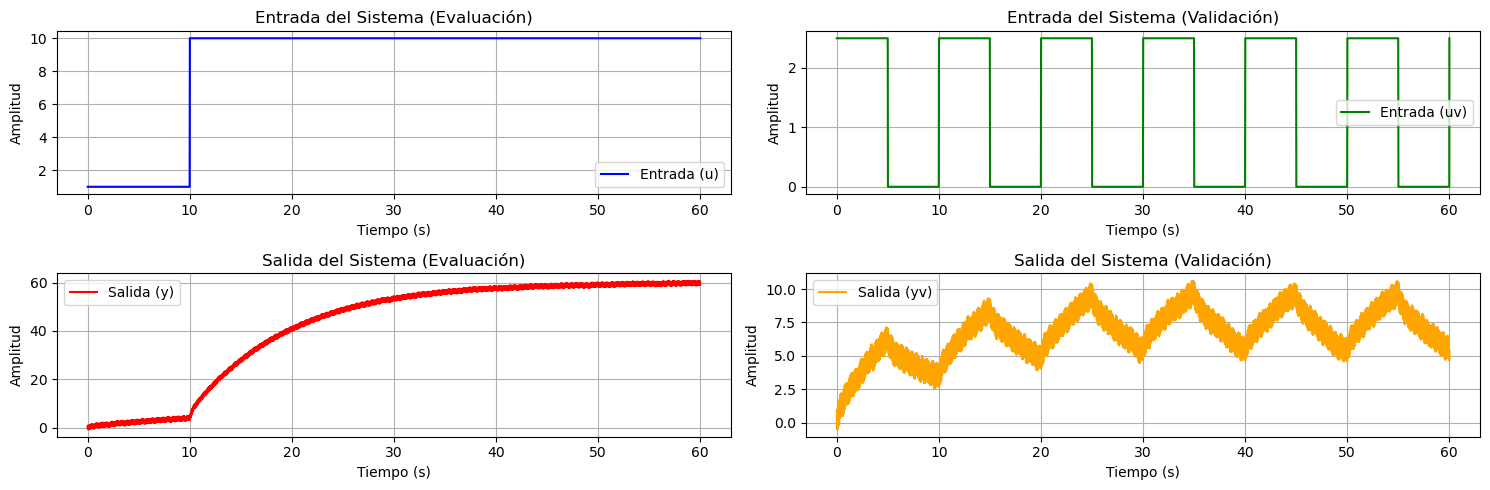

In [4]:
# Visualización de los datos

plt.figure(figsize=(15, 5))

# Entrada evalución
plt.subplot(2, 2, 1)
plt.plot(t, u, label='Entrada (u)', color='blue')
plt.title('Entrada del Sistema (Evaluación)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()  
plt.legend()

# Entrada de validación
plt.subplot(2, 2, 2)
plt.plot(t, uv, label='Entrada (uv)', color='green')
plt.title('Entrada del Sistema (Validación)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()
plt.legend()

# Salida evaluación
plt.subplot(2, 2, 3)
plt.plot(t, y, label='Salida (y)', color='red')
plt.title('Salida del Sistema (Evaluación)')
plt.xlabel('Tiempo (s)')        
plt.ylabel('Amplitud')
plt.grid()
plt.legend()

# Salida validación
plt.subplot(2, 2, 4)
plt.plot(t, yv, label='Salida (yv)', color='orange')
plt.title('Salida del Sistema (Validación)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Rizado es el ruido presente en la señal de salida, 
# que puede ser causado por perturbaciones externas, ruido de medición o variaciones inherentes al sistema. Es importante analizar el rizado para entender la calidad de los datos y su impacto en la identificación del modelo.
# Para modelarlo debemos caracterizarlo con la transformada rapida de fourier para ver el valor de la frecuencia del rizado y así poder modelarlo con un filtro de Butterworth o similar.

CARACTERIZACIÓN

In [14]:
#Parámetro de muestro
N = len(y)  # Número de muestras
Ts = np.mean(np.diff(t))  # Periodo de muestreo
print(f"Periodo de muestreo (Ts): {Ts:.4f} s, Frecuencia de muestreo (Fs): {1/Ts:.2f} Hz")

Periodo de muestreo (Ts): 0.0100 s, Frecuencia de muestreo (Fs): 100.00 Hz


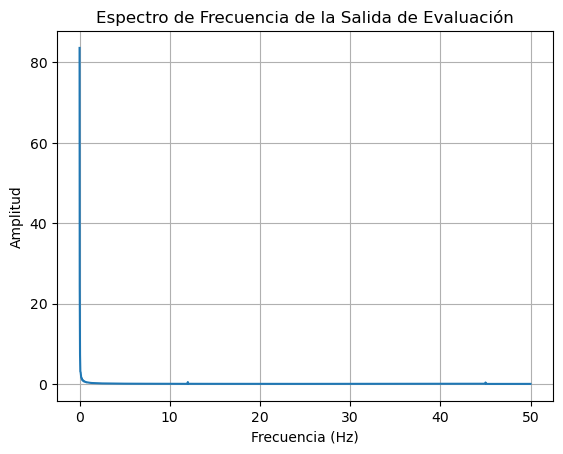

In [15]:
# ANÁLISIS ESPECTRAL FFT

# El análisis espectral permite identificar:
#
# - ruido
# - rizado
# - frecuencias dominantes

yf = fft(y)  # Transformada rápida de Fourier  
xf = fftfreq(N, Ts)[:N//2] # Frecuencias correspondientes

plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.title('Espectro de Frecuencia de la Salida de Evaluación')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid()

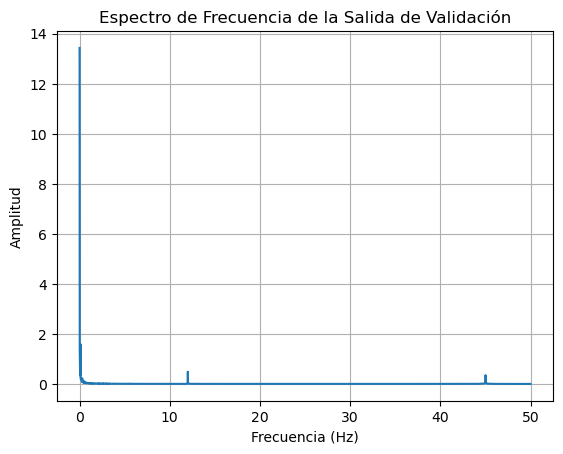

In [9]:
N = len(yv)  # Número de muestras

yf = fft(yv)  # Transformada rápida de Fourier  
xf = fftfreq(N, Ts)[:N//2] # Frecuencias correspondientes

plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.title('Espectro de Frecuencia de la Salida de Validación')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid()

#Muestra la distribución de frecuencias de una señal para identificar el rizado


In [9]:
# Sintaxis para utilizar las estructuras segun la librería

# AR : ar(na, y)
# ARX : arx(na, nb, nk, u, y)
# ARMA : arma(na, nc, y)
# ARMAX : armax(na, nb, nc, nk, u, y)
# OE : oe(nb, nc, nk, y, u)
# BJ : bj(nb, nc, nd, nf, nk, u, y)

In [40]:
# TABLA DE RESULTADOS

resultados = []

TEST CON ESTRUCTURA OE


Evaluando modelo OE orden [1, 1, 1]
  OE  orden nb=1  nf=1  nk=1


c:\Users\MARIANA\anaconda3\envs\biosignals\lib\site-packages\pysid\identification\solvers.py:42: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  phi = concatenate((toeplitz(-y[L-1:Ny-1], -y[L-na:L][::-1]), toeplitz(u[L-nk:Nu-nk], u[L-nk-nb:L-nk+1][::-1])), axis=1)
c:\Users\MARIANA\anaconda3\envs\biosignals\lib\site-packages\scipy\signal\_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)



--- EVALUACIÓN ---


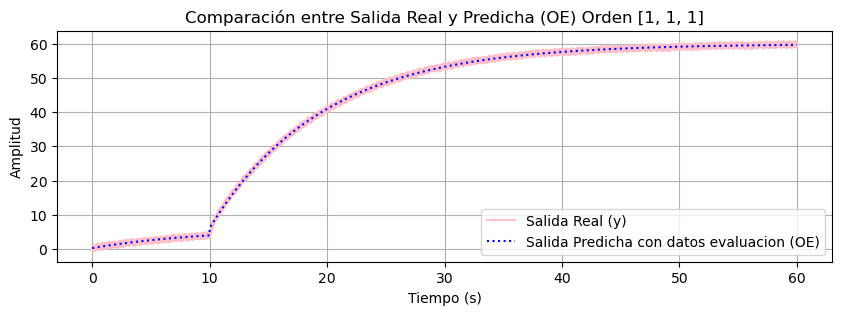

RMSE = 0.5172
MAE  = 0.4191
R²   = 0.9994

--- VALIDACIÓN ---


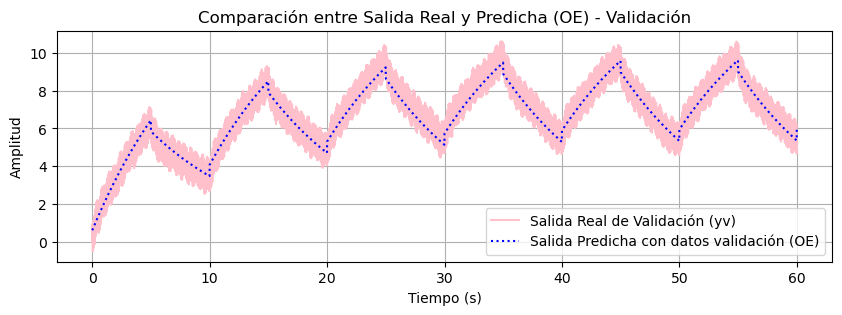

RMSE = 0.5322
MAE  = 0.4338
R²   = 0.9131

Evaluando modelo OE orden [2, 2, 1]
  OE  orden nb=2  nf=2  nk=1


c:\Users\MARIANA\anaconda3\envs\biosignals\lib\site-packages\pysid\identification\solvers.py:42: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  phi = concatenate((toeplitz(-y[L-1:Ny-1], -y[L-na:L][::-1]), toeplitz(u[L-nk:Nu-nk], u[L-nk-nb:L-nk+1][::-1])), axis=1)
c:\Users\MARIANA\anaconda3\envs\biosignals\lib\site-packages\scipy\signal\_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)



--- EVALUACIÓN ---


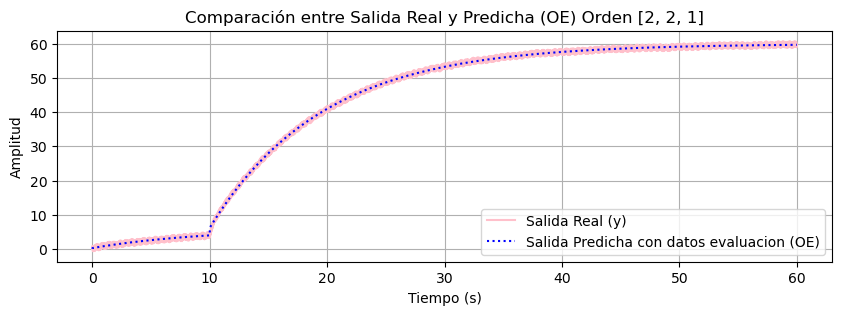

RMSE = 0.5161
MAE  = 0.4187
R²   = 0.9994

--- VALIDACIÓN ---


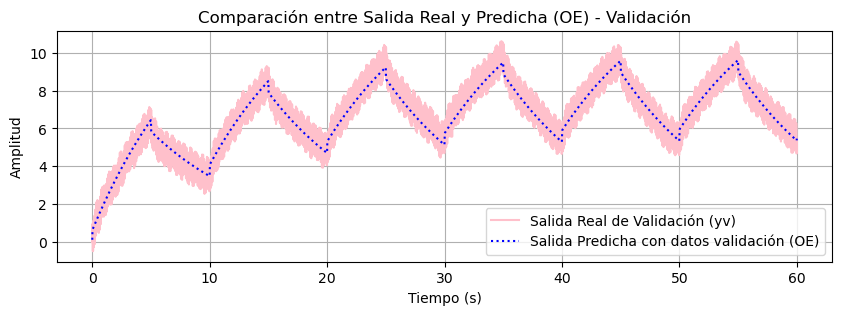

RMSE = 0.5311
MAE  = 0.4325
R²   = 0.9135

Evaluando modelo OE orden [3, 3, 1]
  OE  orden nb=3  nf=3  nk=1


c:\Users\MARIANA\anaconda3\envs\biosignals\lib\site-packages\pysid\identification\solvers.py:42: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  phi = concatenate((toeplitz(-y[L-1:Ny-1], -y[L-na:L][::-1]), toeplitz(u[L-nk:Nu-nk], u[L-nk-nb:L-nk+1][::-1])), axis=1)
c:\Users\MARIANA\anaconda3\envs\biosignals\lib\site-packages\scipy\signal\_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)



--- EVALUACIÓN ---


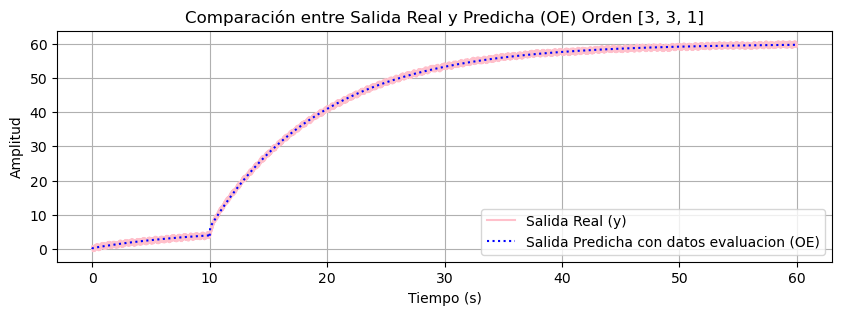

RMSE = 0.5148
MAE  = 0.4181
R²   = 0.9994

--- VALIDACIÓN ---


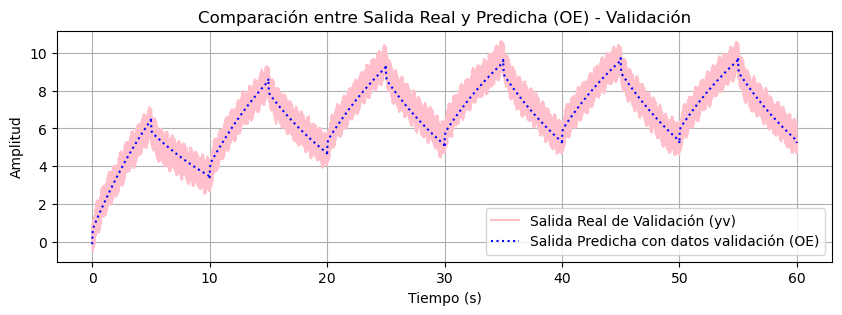

RMSE = 0.5297
MAE  = 0.4317
R²   = 0.9140


In [41]:

# ÓRDENES A EVALUAR

# [nb nf nk]

# nb -> orden numerador
# nf -> orden denominador
# nk -> retardo

# Se usan:
# Bajo  -> [1 1 1]
# Medio -> [2 2 1]
# Alto  -> [3 3 1]

ordenes_oe = [
    [1,1,1],
    [2,2,1],
    [3,3,1]
]

# ============================================================
# CICLO DE EVALUACIÓN OE

for orden in ordenes_oe:

    print("\n================================================")
    print(f"Evaluando modelo OE orden {orden}")
    print("================================================")

    # Extraer órdenes
    nb, nf, nk = orden
    print(f"  OE  orden nb={nb}  nf={nf}  nk={nk}")

    # ========================================================
    # IDENTIFICACIÓN DEL MODELO
    
    model = oe(nb, nf, nk, u, y)

    # ========================================================
    # EXTRACCIÓN DE POLINOMIOS

    B = model.B[0,0]
    F = model.F[0,0]

    # ========================================================
    # CREACIÓN DEL SISTEMA DISCRETO
    system = dlti(B, F, dt=Ts)

    # ========================================================
    # EVALUACIÓN
   
    print("\n--- EVALUACIÓN ---")

    # ========================================================
    # SIMULACIÓN CON DATOS DE EVALUACIÓN

    # Crear señal predichaa usando el modelo
    t_out, y_sim_oe = dlsim(system, u) # y de la funcion de transferencia con la entrada u
    y_sim_oe = y_sim_oe.flatten()  # Aplanar el resultado para facilitar la comparación

    # comparacion real vs predicha

    plt.figure(figsize=(10, 3))
    plt.plot(t, y, label='Salida Real (y)', color='pink')
    plt.plot(t_out, y_sim_oe, label='Salida Predicha con datos evaluacion (OE)', color='blue', linestyle=':')
    plt.title(f'Comparación entre Salida Real y Predicha (OE) Orden {orden}')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid()
    plt.legend()
    plt.show()

    # ========================================================
    # CÁLCULO DE MÉTRICAS

    rmse_eval, mae_eval, r2_eval = calcular_metricas(y, y_sim_oe)


    # ========================================================
    # IMPRESIÓN DE MÉTRICAS
  
    print(f"RMSE = {rmse_eval:.4f}")

    print(f"MAE  = {mae_eval:.4f}")

    print(f"R²   = {r2_eval:.4f}")

    # ======================================================== 
    # VALIDACIÓN
    # ========================================================
   
    print("\n--- VALIDACIÓN ---")

    # Simulación usando datos nuevos

    t_out_val, y_sim_oe_val = dlsim(system, uv) # y de la funcion de transferencia con la entrada uv
    y_sim_oe_val = y_sim_oe_val.flatten()  # Aplanar el resultado para facilitar la comparación

    plt.figure(figsize=(10, 3))
    plt.plot(t, yv, label='Salida Real de Validación (yv)', color='pink')
    plt.plot(t_out_val, y_sim_oe_val, label='Salida Predicha con datos validación (OE)', color='blue', linestyle=':')
    plt.title('Comparación entre Salida Real y Predicha (OE) - Validación')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid()
    plt.legend()
    plt.show()


    # ========================================================
    # MÉTRICAS VALIDACIÓN
    
    rmse_val, mae_val, r2_val = calcular_metricas(yv, y_sim_oe_val)

    print(f"RMSE = {rmse_val:.4f}")
    print(f"MAE  = {mae_val:.4f}")
    print(f"R²   = {r2_val:.4f}")

    # ========================================================
    # GUARDAR RESULTADOS
   
    resultados.append([

        "OE",

        orden,

        rmse_eval,
        mae_eval,
        r2_eval,

        rmse_val,
        mae_val,
        r2_val
    ])

TEST CON ESTRUCTURA ARMAX


Evaluando modelo ARMAX orden [1, 1, 1, 1]


c:\Users\MARIANA\anaconda3\envs\biosignals\lib\site-packages\scipy\signal\_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)



--- EVALUACIÓN ---
RMSE = 0.4795
MAE  = 0.3911
R²   = 0.9995


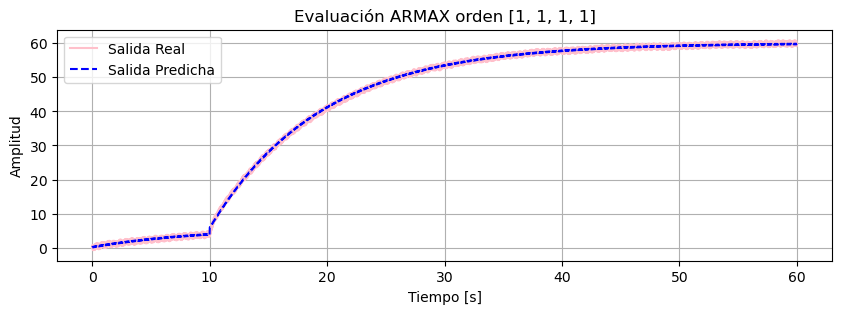


--- VALIDACIÓN ---
RMSE = 0.4905
MAE  = 0.4014
R²   = 0.9262


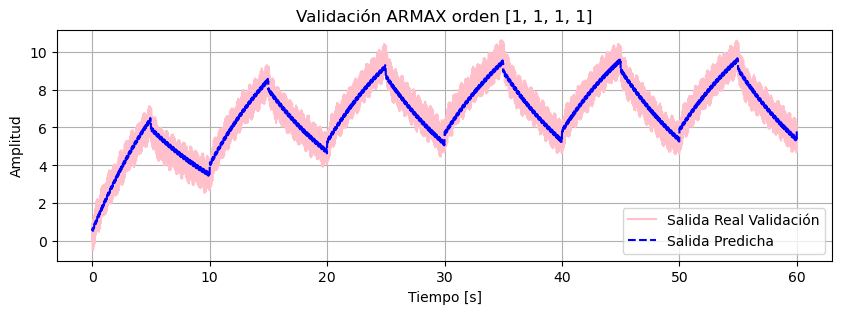


Evaluando modelo ARMAX orden [2, 2, 2, 1]


c:\Users\MARIANA\anaconda3\envs\biosignals\lib\site-packages\scipy\signal\_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)



--- EVALUACIÓN ---
RMSE = 3.1536
MAE  = 2.5664
R²   = 0.9782


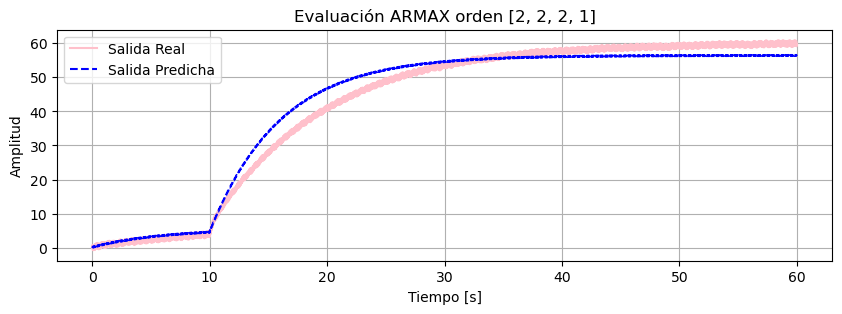


--- VALIDACIÓN ---
RMSE = 0.9361
MAE  = 0.7550
R²   = 0.7313


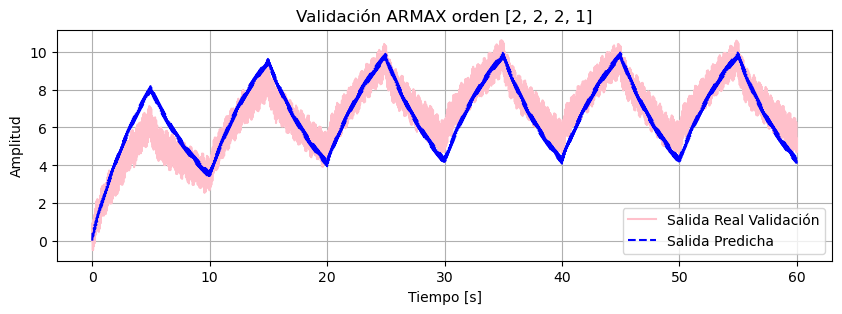


Evaluando modelo ARMAX orden [3, 3, 3, 1]


c:\Users\MARIANA\anaconda3\envs\biosignals\lib\site-packages\scipy\signal\_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)



--- EVALUACIÓN ---
RMSE = 0.4818
MAE  = 0.3920
R²   = 0.9995


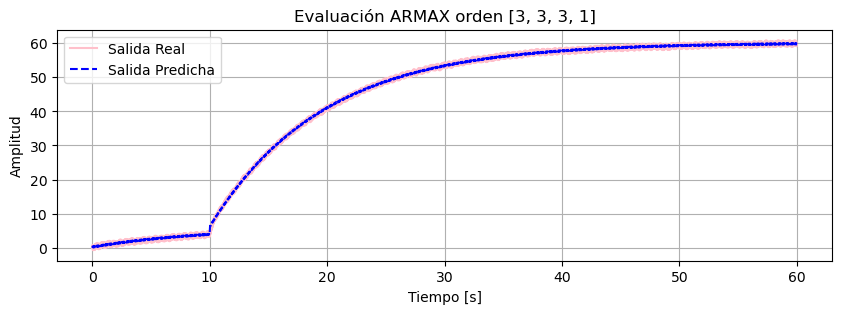


--- VALIDACIÓN ---
RMSE = 0.4968
MAE  = 0.4050
R²   = 0.9243


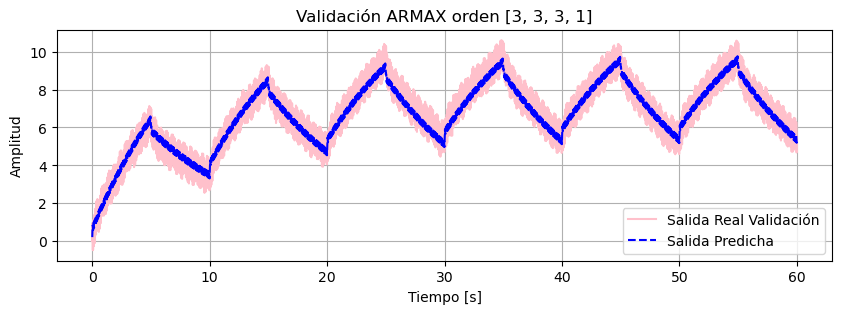

In [42]:
# ============================================================
# ORDENES A EVALUAR

# [na nb nc nk]
#
# na -> orden denominador
# nb -> orden numerador
# nc -> orden ruido
# nk -> retardo

ordenes_armax = [
    # Orden bajo
    [1,1,1,1],
    # Orden medio
    [2,2,2,1],
    # Orden alto
    [3,3,3,1]
]

# ============================================================
# CICLO DE EVALUACIÓN

for orden in ordenes_armax:

    print("\n================================================")
    print(f"Evaluando modelo ARMAX orden {orden}")
    print("================================================")

    # ========================================================
    # EXTRAER ÓRDENES
    
    na, nb, nc, nk = orden

    # ========================================================
    # IDENTIFICACIÓN DEL MODELO
    
    # El modelo se identifica usando:
    #
    # u -> entrada entrenamiento
    # y -> salida entrenamiento

    model = armax(na, nb, nc, nk, u, y)

    # ========================================================
    # EXTRACCIÓN DE POLINOMIOS
    
    # Denominador
    A = model.A[0,0]
    # Numerador
    B = model.B[0,0]
    # Polinomio del ruido
    C = model.C[0,0]

    # ========================================================
    # SISTEMA DINÁMICO PRINCIPAL
    # H(z) = B(z)/A(z)

    system_signal = dlti(B, A, dt=Ts)

    # ========================================================
    # SISTEMA DEL RUIDO
    # Hn(z) = C(z)/A(z)

    system_noise = dlti(C, A, dt=Ts)

    # ========================================================
    # SEÑAL DE RUIDO
    
    # El ARMAX modela explícitamente la dinámica del ruido.
    # Aquí se usa una perturbación senoidal para evaluar el comportamiento del
    # modelo frente a perturbaciones.

    ruido_eval = 0.1 * np.sin(2 * np.pi * 12 * t)
    ruido_val = 0.1 * np.sin(2 * np.pi * 12 * t)

    # ========================================================
    # EVALUACIÓN
   
    print("\n--- EVALUACIÓN ---")
    
    # RESPUESTA DEL SISTEMA

    t_out, y_signal_eval = dlsim(system_signal, u)

    # RESPUESTA DEL RUIDO
  
    t_out, y_noise_eval = dlsim(system_noise, ruido_eval)

    # SALIDA TOTAL
    
    y_sim_armax_eval = (y_signal_eval.flatten() + y_noise_eval.flatten())

    # ========================================================
    # MÉTRICAS EVALUACIÓN
    
    rmse_eval, mae_eval, r2_eval = calcular_metricas(y, y_sim_armax_eval)

    print(f"RMSE = {rmse_eval:.4f}")
    print(f"MAE  = {mae_eval:.4f}")
    print(f"R²   = {r2_eval:.4f}")

    # ========================================================
    # GRÁFICA EVALUACIÓN
   
    plt.figure(figsize=(10,3))
    plt.plot(t, y, label='Salida Real', color='pink')
    plt.plot(t, y_sim_armax_eval, '--', label='Salida Predicha', color='blue')
    plt.title(f'Evaluación ARMAX orden {orden}')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.grid()
    plt.legend()
    plt.show()

    # ========================================================
    # VALIDACIÓN
    # ========================================================
    
    print("\n--- VALIDACIÓN ---")

    # RESPUESTA DEL SISTEMA
    
    t_out, y_signal_val = dlsim(system_signal, uv)
    
    # RESPUESTA DEL RUIDO
    
    t_out, y_noise_val = dlsim(system_noise, ruido_val)
    
    # SALIDA TOTAL
    
    y_sim_armax_val = (y_signal_val.flatten() + y_noise_val.flatten())

    # ========================================================
    # MÉTRICAS VALIDACIÓN
    
    rmse_val, mae_val, r2_val = calcular_metricas(yv, y_sim_armax_val)

    print(f"RMSE = {rmse_val:.4f}")
    print(f"MAE  = {mae_val:.4f}")
    print(f"R²   = {r2_val:.4f}")

    # ========================================================
    # GRÁFICA VALIDACIÓN
    
    plt.figure(figsize=(10,3))
    plt.plot(t, yv, label='Salida Real Validación', color='pink')
    plt.plot(t, y_sim_armax_val, '--', label='Salida Predicha', color='blue')
    plt.title(f'Validación ARMAX orden {orden}')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.grid()
    plt.legend()
    plt.show()

    # ========================================================
    # GUARDAR RESULTADOS
    
    resultados.append([

        "ARMAX",

        orden,

        rmse_eval,
        mae_eval,
        r2_eval,

        rmse_val,
        mae_val,
        r2_val
    ])


In [36]:
# ============================================================
# TABLA FINAL
# ============================================================

tabla = pd.DataFrame(

    resultados,

    columns=[

        "Modelo",

        "Orden",

        "RMSE Eval",
        "MAE Eval",
        "R2 Eval",

        "RMSE Val",
        "MAE Val",
        "R2 Val"
    ]
)


print("\n================================================")
print("TABLA FINAL DE RESULTADOS")
print("================================================")

print(tabla)





TABLA FINAL DE RESULTADOS
  Modelo         Orden  RMSE Eval  MAE Eval   R2 Eval  RMSE Val   MAE Val  \
0     OE     [1, 1, 1]   0.517182  0.419121  0.999414  0.532223  0.433800   
1     OE     [2, 2, 1]   0.516108  0.418673  0.999416  0.531110  0.432520   
2     OE     [3, 3, 1]   0.514832  0.418109  0.999419  0.529650  0.431740   
3  ARMAX  [1, 1, 1, 1]   0.479463  0.391129  0.999496  0.490509  0.401446   
4  ARMAX  [2, 2, 2, 1]   3.153612  2.566390  0.978197  0.936126  0.755005   
5  ARMAX  [3, 3, 3, 1]   0.481769  0.391955  0.999491  0.496752  0.405045   

     R2 Val  
0  0.913139  
1  0.913502  
2  0.913977  
3  0.926222  
4  0.731277  
5  0.924331  


In [37]:
# El mejor modelo

mejor_modelo = tabla.loc[tabla['R2 Val'].idxmax()]
print("\n================================================")
print("MEJOR MODELO SEGÚN R² DE VALIDACIÓN")
print("================================================")
print(mejor_modelo)



MEJOR MODELO SEGÚN R² DE VALIDACIÓN
Modelo              ARMAX
Orden        [1, 1, 1, 1]
RMSE Eval        0.479463
MAE Eval         0.391129
R2 Eval          0.999496
RMSE Val         0.490509
MAE Val          0.401446
R2 Val           0.926222
Name: 3, dtype: object
